# Universe Time-Line

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Polygon

In [19]:
plt.rcParams["figure.figsize"] = (4,3)
plt.rcParams["axes.labelsize"] = 'xx-large'
plt.rcParams['axes.titlesize'] = 'xx-large'
plt.rcParams['xtick.labelsize']= 'xx-large'
plt.rcParams['ytick.labelsize']= 'xx-large'

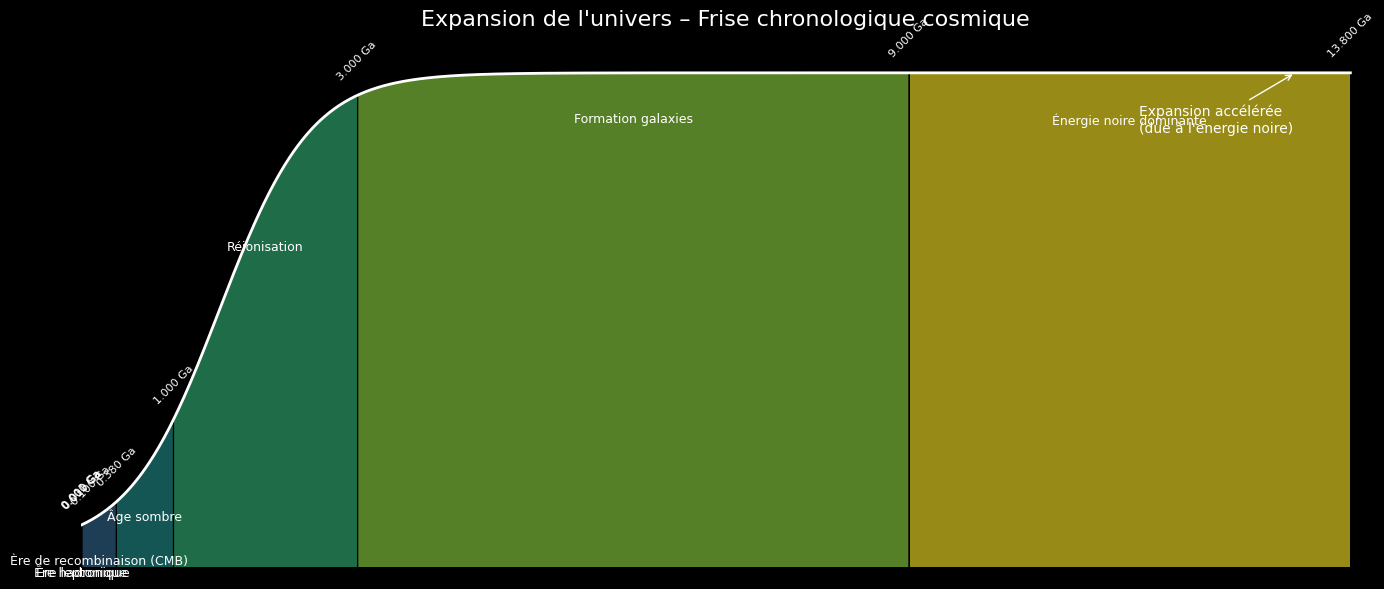

In [3]:
# Création de la figure
fig, ax = plt.subplots(figsize=(14, 6))
ax.set_xlim(0, 14)
ax.set_ylim(0, 1.3)
ax.axis("off")

# Axe du temps : 0 (Big Bang) → 13.8 (présent)
x = np.linspace(0, 13.8, 1000)

# Fonction d'expansion stylisée (type sigmoïde)
# Approximation artistique pour illustrer la phase d'accélération
scale_factor = (np.tanh((x - 1.5)) + 1) / 2  # Croissance lente puis rapide
scale_factor = 0.05 + scale_factor * 1.2     # Étendre verticalement

# Zones colorées représentant les différentes ères
zones = [
    (0, 0.00038, "#440154", "Ère leptonique"),
    (0.00038, 0.003, "#443983", "Ère hadronique"),
    (0.003, 0.38, "#31688e", "Ère de recombinaison (CMB)"),
    (0.38, 1.0, "#21908d", "Âge sombre"),
    (1.0, 3.0, "#35b779", "Réionisation"),
    (3.0, 9.0, "#90d743", "Formation galaxies"),
    (9.0, 13.8, "#fde725", "Énergie noire dominante"),
]

# Dessiner chaque zone comme un polygone entre deux courbes
for start, end, color, label in zones:
    mask = (x >= start) & (x <= end)
    x_zone = x[mask]
    y_bottom = np.zeros_like(x_zone)
    y_top = scale_factor[mask]
    verts = np.column_stack([x_zone, y_bottom])
    verts = np.vstack([verts, np.column_stack([x_zone[::-1], y_top[::-1]])])
    poly = Polygon(verts, closed=True, facecolor=color, alpha=0.6, edgecolor='none')
    ax.add_patch(poly)

# Tracer la courbe d'expansion elle-même
ax.plot(x, scale_factor, color="white", linewidth=2, label="Expansion de l'univers")

# Repères temporels
repères = [0.0001, 0.001, 0.01, 0.1, 0.38, 1, 3, 9, 13.8]
for t in repères:
    y = np.interp(t, x, scale_factor)
    ax.text(t, y + 0.035, f"{t:.3f} Ga", ha='center', va='bottom', fontsize=8, color="white", rotation=45)

# Annotations des zones
for start, end, color, label in zones:
    t = (start + end) / 2
    y = np.interp(t, x, scale_factor)
    ax.text(t, y - 0.1, label, ha="center", va="top", fontsize=9, color="white")

# Annotation sur l'expansion actuelle
ax.annotate("Expansion accélérée\n(due à l'énergie noire)",
            xy=(13.2, scale_factor[-1]), xytext=(11.5, 1.1),
            arrowprops=dict(arrowstyle="->", color="white"),
            color="white", fontsize=10, ha="left")

# Titre
ax.set_title("Expansion de l'univers – Frise chronologique cosmique", fontsize=16, color="white", pad=20)

# Fond noir
fig.patch.set_facecolor('black')
ax.set_facecolor('black')

plt.tight_layout()
plt.show()

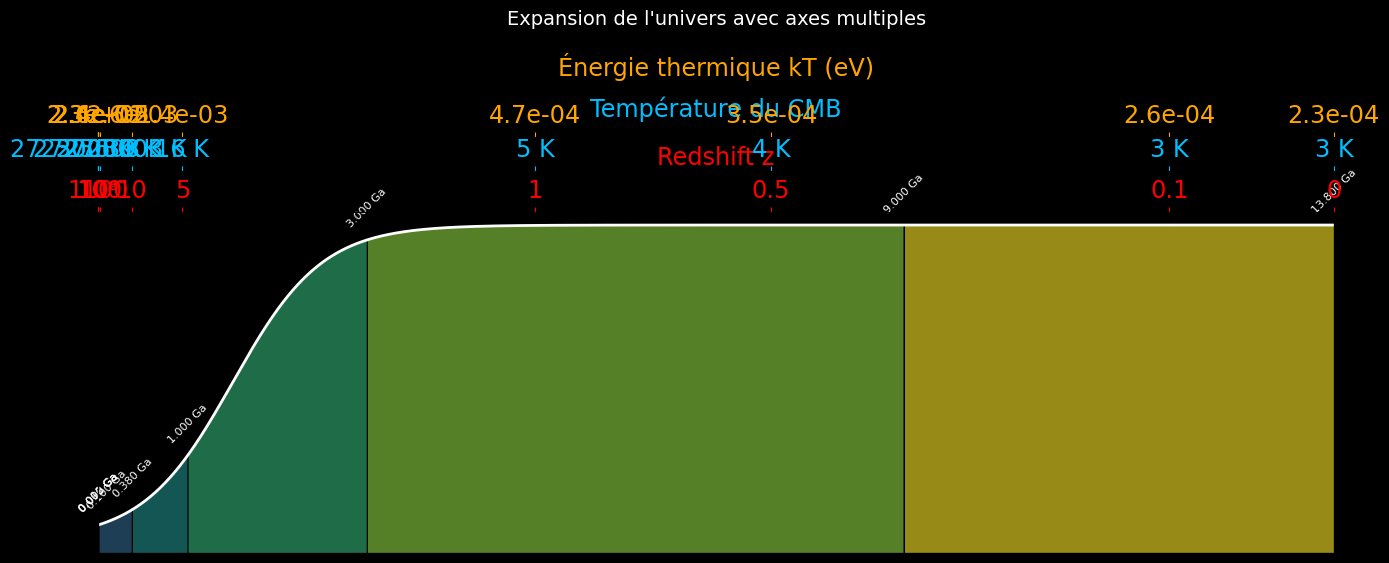

In [20]:
# Constantes cosmologiques simplifiées
T0 = 2.725  # Température actuelle du CMB (K)
k_B_eV = 8.617e-5  # Constante de Boltzmann en eV/K

# Redshifts et conversions associées
z_vals = np.array([1e9, 1e6, 1e3, 1100, 100, 10, 5, 1, 0.5, 0.1, 0])
labels_z = ['10⁹', '10⁶', '10³', '1100', '100', '10', '5', '1', '0.5', '0.1', '0']

# Approximation de l'âge de l'univers en Ga en fonction de z
age_vals = 13.8 / (1 + z_vals)**1.5  # Approximation qualitative

# Températures et énergies thermiques correspondantes
T_vals = T0 * (1 + z_vals)
E_vals = T_vals * k_B_eV

# Axe x (temps en Ga)
x = np.linspace(0, 13.8, 1000)
scale_factor = (np.tanh((x - 1.5)) + 1) / 2
scale_factor = 0.05 + scale_factor * 1.2

# Définition des zones cosmiques
zones = [
    (0, 0.00038, "#440154", "Ère leptonique"),
    (0.00038, 0.003, "#443983", "Ère hadronique"),
    (0.003, 0.38, "#31688e", "Ère de recombinaison"),
    (0.38, 1.0, "#21908d", "Âge sombre"),
    (1.0, 3.0, "#35b779", "Réionisation"),
    (3.0, 9.0, "#90d743", "Formation des galaxies"),
    (9.0, 13.8, "#fde725", "Énergie noire dominante"),
]

# Création de la figure
fig, ax_time = plt.subplots(figsize=(14, 6))
ax_time.set_xlim(0, 13.8)
ax_time.set_ylim(0, 1.3)
ax_time.axis("off")

# Dessin des zones cosmologiques
for start, end, color, label in zones:
    mask = (x >= start) & (x <= end)
    x_zone = x[mask]
    y_bottom = np.zeros_like(x_zone)
    y_top = scale_factor[mask]
    verts = np.column_stack([x_zone, y_bottom])
    verts = np.vstack([verts, np.column_stack([x_zone[::-1], y_top[::-1]])])
    poly = Polygon(verts, closed=True, facecolor=color, alpha=0.6, edgecolor='none')
    ax_time.add_patch(poly)

# Courbe d'expansion
ax_time.plot(x, scale_factor, color="white", linewidth=2)

# Étiquettes temps en Ga
for t in [0.0001, 0.001, 0.01, 0.1, 0.38, 1, 3, 9, 13.8]:
    y = np.interp(t, x, scale_factor)
    ax_time.text(t, y + 0.04, f"{t:.3f} Ga", ha='center', va='bottom', fontsize=8, color="white", rotation=45)

# Titre
ax_time.set_title("Expansion de l'univers avec axes multiples", fontsize=14, color="white", pad=20)

# --- Axes secondaires ---

# Axe redshift
ax_z = ax_time.twiny()
ax_z.set_xlim(ax_time.get_xlim())
ax_z.set_xticks(age_vals)
ax_z.set_xticklabels(labels_z)
ax_z.xaxis.set_ticks_position('top')
ax_z.tick_params(axis='x', colors='red')
ax_z.set_xlabel("Redshift z", color='red', labelpad=10)

# Axe température
ax_T = ax_time.twiny()
ax_T.spines["top"].set_position(("axes", 1.12))
ax_T.set_xlim(ax_time.get_xlim())
ax_T.set_xticks(age_vals)
ax_T.set_xticklabels([f"{T:.0f} K" for T in T_vals])
ax_T.tick_params(axis='x', colors='deepskyblue')
ax_T.set_xlabel("Température du CMB", color='deepskyblue', labelpad=15)

# Axe énergie thermique
ax_E = ax_time.twiny()
ax_E.spines["top"].set_position(("axes", 1.22))
ax_E.set_xlim(ax_time.get_xlim())
ax_E.set_xticks(age_vals)
ax_E.set_xticklabels([f"{E:.1e}" for E in E_vals])
ax_E.tick_params(axis='x', colors='orange')
ax_E.set_xlabel("Énergie thermique kT (eV)", color='orange', labelpad=20)

# Fond noir
fig.patch.set_facecolor('black')
ax_time.set_facecolor('black')

plt.tight_layout()
plt.show()

In [30]:
def format_energy(E):
    if E < 1e-3:
        return f"{E*1e3:.1f} meV"
    elif E < 1:
        return f"{E:.2f} eV"
    elif E < 1e3:
        return f"{E:.1f} eV"
    else:
        return f"{E/1e3:.1f} keV"

def format_temperature_with_power_of_10(x, sig=2):
    # Formate x en notation scientifique avec 'sig' chiffres significatifs
    # Exemple: 5.23e8 -> '5.2 10^{8}'
    s = f"{x:.{sig}e}"  # notation scientifique ex: 5.23e+08
    mantissa, exp = s.split('e')
    exp = int(exp)  # Convertit exposant en entier
    # Enlève le .0 si mantissa est un entier comme 5.0
    if mantissa.endswith('.0'):
        mantissa = mantissa[:-2]
    return f"{mantissa} " + f"$10^{{{exp}}}$ K"

['2.7 $10^{9}$ K', '2.7 $10^{6}$ K', '2.7 $10^{3}$ K', '3 $10^{3}$ K', '2.8 $10^{2}$ K', '3 $10^{1}$ K', '1.6 $10^{1}$ K', '5.5 $10^{0}$ K', '4.1 $10^{0}$ K', '3 $10^{0}$ K', '2.7 $10^{0}$ K']


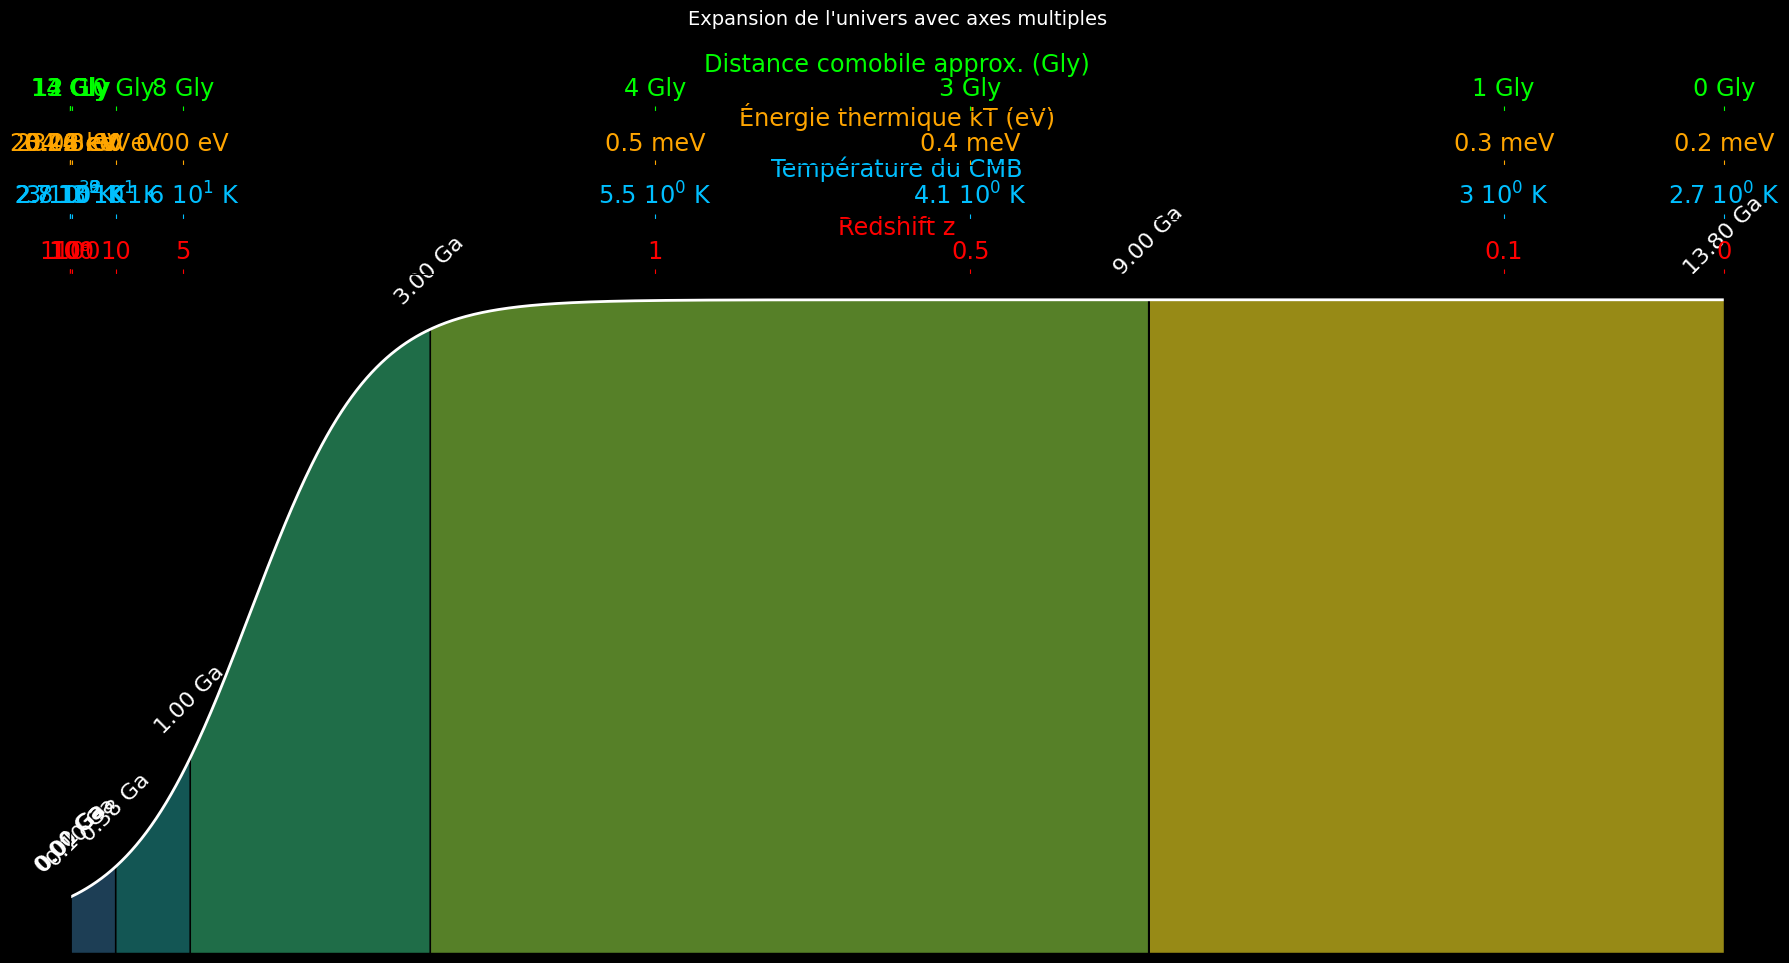

In [32]:


# Constantes cosmologiques simplifiées
T0 = 2.725  # Température actuelle du CMB (K)
k_B_eV = 8.617e-5  # Constante de Boltzmann en eV/K

# Redshifts et conversions associées
z_vals = np.array([1e9, 1e6, 1e3, 1100, 100, 10, 5, 1, 0.5, 0.1, 0])
labels_z = ['10⁹', '10⁶', '10³', '1100', '100', '10', '5', '1', '0.5', '0.1', '0']

# Approximation de l'âge de l'univers en Ga pour chaque z
age_vals = 13.8 / (1 + z_vals)**1.5  # Approximation qualitative

# Température du CMB
T_vals = T0 * (1 + z_vals)
#T_vals_labels = [f"{T:.2f}".replace(",", " ") + " K" for T in T_vals]
#T_vals_labels = [f"{T:.0g} K" for T in T_vals]
T_vals_labels = [format_temperature_with_power_of_10(T, 1) for T in T_vals]
print(T_vals_labels)

# Énergie thermique kT en eV
E_vals = T_vals * k_B_eV
E_vals_labels = [f"{format_energy(E)}" for E in E_vals]


# Distance comobile approximative (en Gly)
d_comoving_vals = 13.8 * (1 - 1 / np.sqrt(1 + z_vals))
d_comoving_vals_labels = [f"{round(d)} Gly" for d in d_comoving_vals]

# Axe x (temps en Ga)
x = np.linspace(0, 13.8, 1000)

# Facteur d’échelle stylisé
scale_factor = (np.tanh((x - 1.5)) + 1) / 2
scale_factor = 0.05 + scale_factor * 1.2

# Définition des zones cosmiques colorées
zones = [
    (0, 0.00038, "#440154", "Ère leptonique"),
    (0.00038, 0.003, "#443983", "Ère hadronique"),
    (0.003, 0.38, "#31688e", "Ère de recombinaison"),
    (0.38, 1.0, "#21908d", "Âge sombre"),
    (1.0, 3.0, "#35b779", "Réionisation"),
    (3.0, 9.0, "#90d743", "Formation des galaxies"),
    (9.0, 13.8, "#fde725", "Énergie noire dominante"),
]

# Création de la figure
fig, ax_time = plt.subplots(figsize=(18, 10))
ax_time.set_xlim(0, 13.8)
ax_time.set_ylim(0, 1.3)
ax_time.axis("off")

# Dessin des zones cosmologiques
for start, end, color, label in zones:
    mask = (x >= start) & (x <= end)
    x_zone = x[mask]
    y_bottom = np.zeros_like(x_zone)
    y_top = scale_factor[mask]
    verts = np.column_stack([x_zone, y_bottom])
    verts = np.vstack([verts, np.column_stack([x_zone[::-1], y_top[::-1]])])
    poly = Polygon(verts, closed=True, facecolor=color, alpha=0.6, edgecolor='none')
    ax_time.add_patch(poly)

# Courbe d'expansion
ax_time.plot(x, scale_factor, color="white", linewidth=2)

# Étiquettes temps en Ga
for t in [0.0001, 0.001, 0.01, 0.1, 0.38, 1, 3, 9, 13.8]:
    y = np.interp(t, x, scale_factor)
    ax_time.text(t, y + 0.04, f"{t:.2f} Ga", ha='center', va='bottom', fontsize=16, color="white", rotation=45)

# Titre principal
ax_time.set_title("Expansion de l'univers avec axes multiples", fontsize=14, color="white", pad=20)


# Fond noir
fig.patch.set_facecolor('black')
ax_time.set_facecolor('black')

# Ajustement manuel du layout (au lieu de tight_layout)
plt.subplots_adjust(top=0.9)

# Positionnement précis des axes secondaires
offsets = [1.0, 1.08, 1.16, 1.24]  # positions Y pour z, T, kT, distance

# Redshift z
ax_z = ax_time.twiny()
ax_z.spines["top"].set_position(("axes", offsets[0]))
ax_z.set_xlim(ax_time.get_xlim())
ax_z.set_xticks(age_vals)
ax_z.set_xticklabels(labels_z)
ax_z.tick_params(axis='x', colors='red')
ax_z.set_xlabel("Redshift z", color='red')

# Température
ax_T = ax_time.twiny()
ax_T.spines["top"].set_position(("axes", offsets[1]))
ax_T.set_xlim(ax_time.get_xlim())
ax_T.set_xticks(age_vals)
#ax_T.set_xticklabels([f"{T:.0f} K" for T in T_vals])
ax_T.set_xticklabels(T_vals_labels)
ax_T.tick_params(axis='x', colors='deepskyblue')
ax_T.set_xlabel("Température du CMB", color='deepskyblue')

# Énergie kT
ax_E = ax_time.twiny()
ax_E.spines["top"].set_position(("axes", offsets[2]))
ax_E.set_xlim(ax_time.get_xlim())
ax_E.set_xticks(age_vals)
#ax_E.set_xticklabels([f"{E:.1e}" for E in E_vals])
ax_E.set_xticklabels(E_vals_labels)
ax_E.tick_params(axis='x', colors='orange')
ax_E.set_xlabel("Énergie thermique kT (eV)", color='orange')

# Distance comobile
ax_D = ax_time.twiny()
ax_D.spines["top"].set_position(("axes", offsets[3]))
ax_D.set_xlim(ax_time.get_xlim())
ax_D.set_xticks(age_vals)
#ax_D.set_xticklabels([f"{d:.1f}" for d in d_comoving_vals])
ax_D.set_xticklabels(d_comoving_vals_labels)
ax_D.tick_params(axis='x', colors='lime')
ax_D.set_xlabel("Distance comobile approx. (Gly)", color='lime')


plt.tight_layout()
plt.show()